MODEL_KIND      = nagaosa
coupling        = phi = 0.3
TARGET_FILLING  = 0.41666667
mu              = -0.0000000000
Npatch          = 48
band_index      = 1

=== Harmonic subspace weights ===


,l,subspace_weight,subspace_dim
0,0,4.229954e-34,1.0
1,1,1.418771e-64,2.0
2,2,2.257900e-32,2.0
3,3,4.123246e-64,2.0
4,4,2.518205e-34,2.0
5,5,3.657277e-64,2.0
6,6,5.656533e-33,2.0
7,7,2.676795e-63,2.0
8,8,3.874029e-32,2.0
9,residual,1.000000e+00,NaN



=== Raw overlaps with individual harmonic templates ===


,template,abs_overlap
0,cos(8θ),1.966924e-16
1,cos(2θ),1.501811e-16
2,cos(6θ),7.518632e-17
3,l=0 const,2.056685e-17
4,cos(4θ),1.472554e-17
5,sin(8θ),7.236825e-18
6,sin(4θ),5.914294e-18
7,sin(2θ),4.962298e-18
8,sin(6θ),1.884291e-18
9,cos(7θ),6.058566e-32


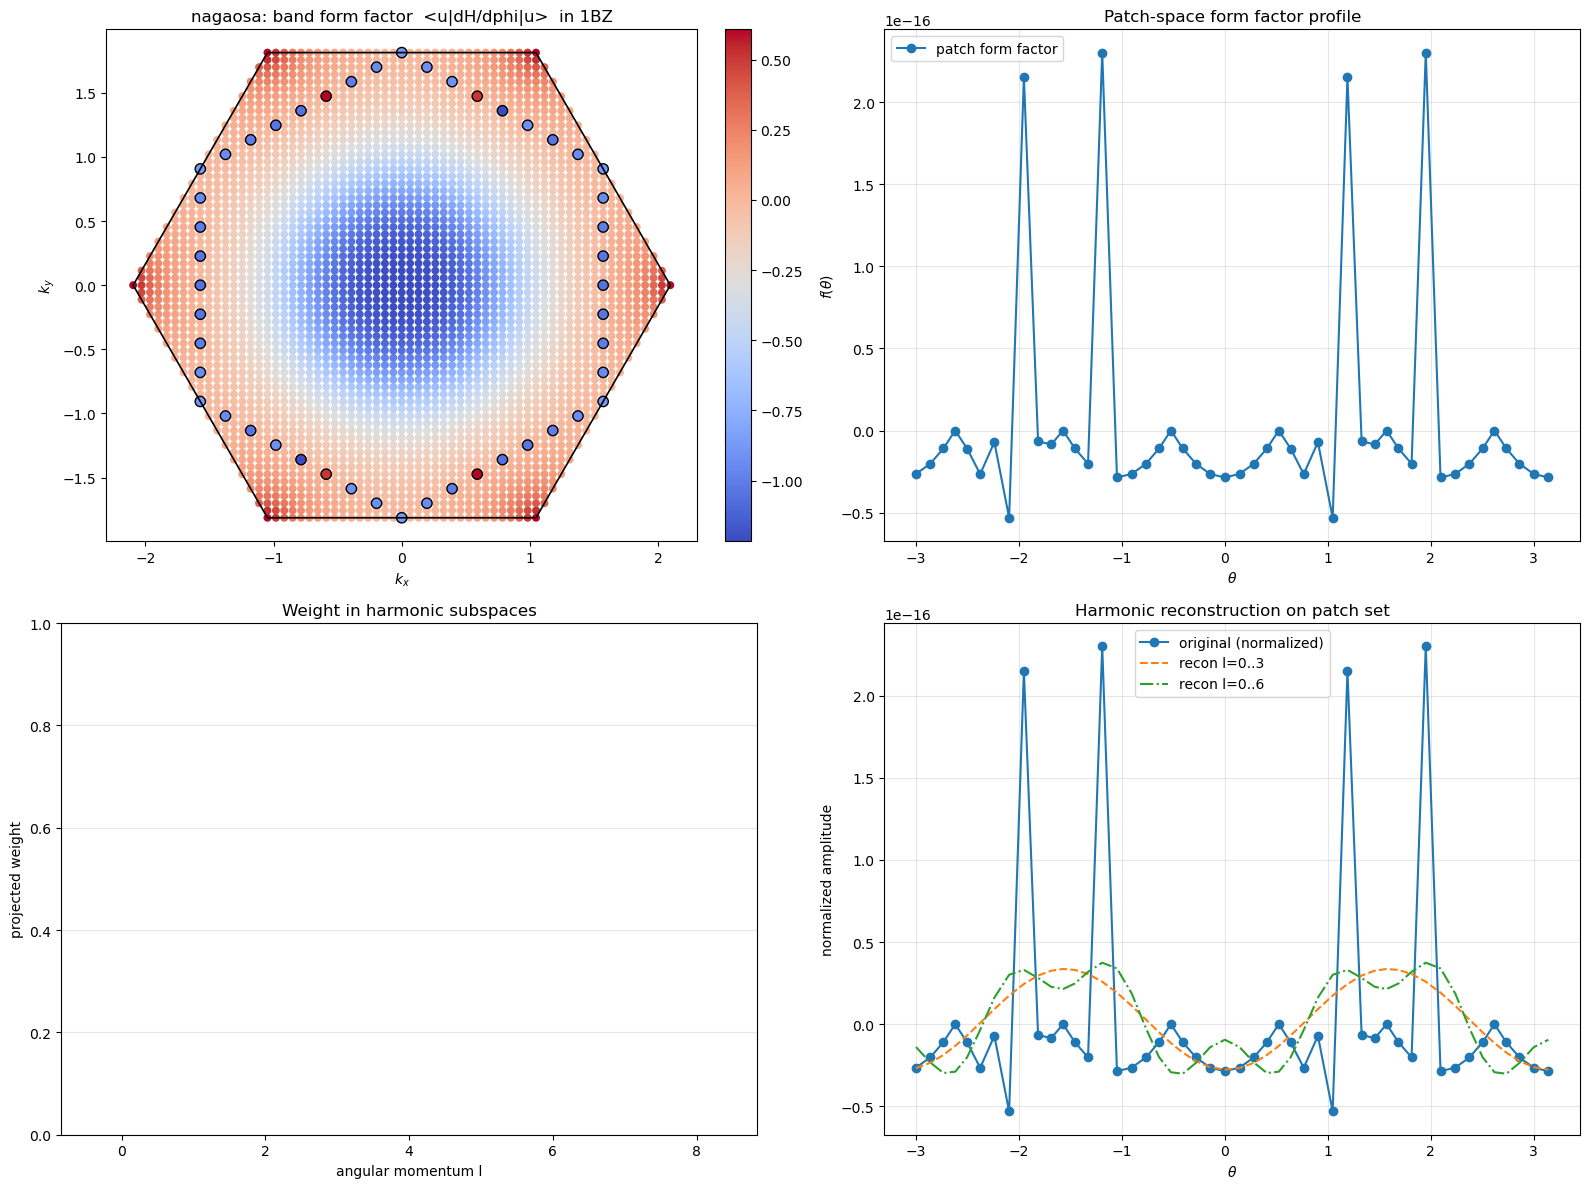


=== Summary ===
model                : nagaosa
coupling             : phi = 0.3
band index           : 1
filling              : 0.4166666666666667
mu                    = -0.000000000000
patch_ff min/max      = (-5.31293926e-17, 2.30102166e-16)
patch_ff mean         = 2.96856930e-18
patch_ff std          = 6.72931216e-17
largest raw harmonic overlap = cos(8θ)  ->  0.00000000
sum harmonic weights l=0..8 = 0.00000000
residual weight             = 1.00000000


In [6]:
# ============================================================
# Current-like form factor test from noninteracting models
#   - supports: KagomeNagaosa, KagomeKaneMeleSOC (l1 only, l2=0)
#   - objective definition:
#         f_n(k) = <u_n(k) | dH/dlambda | u_n(k)>
#     where lambda = phi   (Nagaosa)
#                  = l1    (Kane-Mele NN SOC)
#   - then compare this patch-space form factor with harmonic states
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import importlib.util
from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# User controls
# ------------------------------------------------------------
MODEL_KIND = "nagaosa"         # "nagaosa" or "kanemele_l1"
TARGET_FILLING = 5.0 / 12.0    # van Hove filling for kagome dispersive band
BAND_INDEX = 1                 # middle dispersive band in 3x3 spinless block
POINTS_PER_EDGE = 8            # patch density: 1->6, 2->12, 4->24, 8->48 ...
PROJECT_TO_FS_POINTS = True
GAUGE_FIX = True
CLOSE_LOOP_GAUGE = True
GAUGE_ANCHOR = "max_component" # same style as your notebook
REMOVE_DUPLICATE_M_MODG = False
LMAX = 8                       # harmonic analysis up to l = LMAX

# model parameters
T_HOP = 1.0

# choose a finite coupling to evaluate the Bloch states
# (the operator is dH/dlambda, but the eigenvectors are taken at this finite lambda)
PHI_EVAL = 0.30               # for KagomeNagaosa
L1_EVAL  = 0.30               # for KagomeKaneMeleSOC
L2_EVAL  = 0.00               # force only l1
EF_GRID_N = 140               # for EF_from_filling
BZ_GRID_N = 65                # momentum-space visualization grid

# ------------------------------------------------------------
# Load your uploaded modules by file path
# ------------------------------------------------------------
def _load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, str(path))
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

import noninteracting as nonint
import patching
KagomeNagaosa = nonint.KagomeNagaosa
KagomeKaneMeleSOC = nonint.KagomeKaneMeleSOC
build_exactM_patchset = patching.build_exactM_patchset
hex_bz_vertices = patching.hex_bz_vertices


# ------------------------------------------------------------
# Model construction
# ------------------------------------------------------------
if MODEL_KIND.lower() == "nagaosa":
    model = KagomeNagaosa(
        {"t": T_HOP, "phi": PHI_EVAL},
        spin=False,
        B=None,
    )
    coupling_name = "phi"
    coupling_value = PHI_EVAL

elif MODEL_KIND.lower() == "kanemele_l1":
    model = KagomeKaneMeleSOC(
        {"t": T_HOP, "l1": L1_EVAL, "l2": L2_EVAL},
        spin=False,
        B=None,
    )
    coupling_name = "l1"
    coupling_value = L1_EVAL

else:
    raise ValueError("MODEL_KIND must be 'nagaosa' or 'kanemele_l1'.")

# ------------------------------------------------------------
# Chemical potential and patch set
# ------------------------------------------------------------
mu = model.EF_from_filling(TARGET_FILLING, N=EF_GRID_N)

patchset = build_exactM_patchset(
    model,
    slice(0, 3),              # spinless / single-spin 3x3 block
    BAND_INDEX,
    points_per_edge=POINTS_PER_EDGE,
    remove_duplicate_M_modG=REMOVE_DUPLICATE_M_MODG,
    gauge_fix=GAUGE_FIX,
    close_loop_gauge=CLOSE_LOOP_GAUGE,
    gauge_anchor=GAUGE_ANCHOR,
    project_to_fs_points=PROJECT_TO_FS_POINTS,
    mu=mu,
)

print(f"MODEL_KIND      = {MODEL_KIND}")
print(f"coupling        = {coupling_name} = {coupling_value}")
print(f"TARGET_FILLING  = {TARGET_FILLING:.8f}")
print(f"mu              = {mu:.10f}")
print(f"Npatch          = {patchset.Npatch}")
print(f"band_index      = {patchset.band_index}")

# ------------------------------------------------------------
# Algebraic current-like operator O(k) = dH/dlambda
# ------------------------------------------------------------
def dH_dphi_nagaosa(model, kx, ky):
    """
    Analytic derivative for KagomeNagaosa spinless 3x3 block.

    From the model definition:
      AB = -2 t exp(+i phi/3) cos(k·delta1)
      AC = -2 t exp(-i phi/3) cos(k·delta2)
      BC = -2 t exp(+i phi/3) cos(k·delta3)

    so d/dphi just differentiates the phase factors.
    """
    t = model.parameters["t"]
    phi = model.parameters["phi"]
    kvec = np.array([kx, ky], dtype=float)

    c1 = np.cos(np.dot(model.delta1, kvec))
    c2 = np.cos(np.dot(model.delta2, kvec))
    c3 = np.cos(np.dot(model.delta3, kvec))

    AB = -2.0 * t * np.exp(1j * phi / 3.0) * c1
    AC = -2.0 * t * np.exp(-1j * phi / 3.0) * c2
    BC = -2.0 * t * np.exp(1j * phi / 3.0) * c3

    dAB = (1j / 3.0) * AB
    dAC = (-1j / 3.0) * AC
    dBC = (1j / 3.0) * BC

    O = np.array(
        [
            [0.0,               dAB,               dAC],
            [np.conjugate(dAB), 0.0,               dBC],
            [np.conjugate(dAC), np.conjugate(dBC), 0.0],
        ],
        dtype=complex,
    )
    # Should be Hermitian:
    O = 0.5 * (O + O.conjugate().T)
    return O

def dH_dl1_kanemele(model, kx, ky, s=+1):
    """
    Analytic derivative wrt l1 for KagomeKaneMeleSOC.
    Use the same sign convention as the model's spin-up block.
    """
    f1, f2, f3, _, _, _ = model.f(kx, ky)
    O = np.array(
        [
            [0.0,            1j * s * f1,   -1j * s * f2],
            [-1j * s * f1,   0.0,            1j * s * f3],
            [1j * s * f2,   -1j * s * f3,    0.0],
        ],
        dtype=complex,
    )
    O = 0.5 * (O + O.conjugate().T)
    return O

def operator_matrix(model, kx, ky):
    if MODEL_KIND.lower() == "nagaosa":
        return dH_dphi_nagaosa(model, kx, ky)
    elif MODEL_KIND.lower() == "kanemele_l1":
        return dH_dl1_kanemele(model, kx, ky, s=+1)
    raise RuntimeError("Unknown MODEL_KIND.")

# ------------------------------------------------------------
# Band-resolved scalar form factor:
#     f_n(k) = <u_n(k)| O(k) |u_n(k)>
# gauge-invariant under u_n(k) -> e^{i chi(k)} u_n(k)
# ------------------------------------------------------------
def band_form_factor(model, kx, ky, band_index):
    evals, evecs = model.eigenstate(kx, ky)
    u = np.asarray(evecs[:, band_index], dtype=complex)
    O = operator_matrix(model, kx, ky)
    val = np.vdot(u, O @ u)
    # for Hermitian O this should be real up to tiny numerical noise
    val = np.real_if_close(val, tol=1000)
    return float(np.real(val))

# ------------------------------------------------------------
# Patch-angle / harmonic helpers
# Keep this consistent with your notebook style:
# scalar templates on patch angle theta
# ------------------------------------------------------------
def _normalize_vec(v, tol=1e-14):
    v = np.asarray(v, dtype=complex).reshape(-1)
    n = np.linalg.norm(v)
    if n <= tol:
        return v.copy()
    return v / n

def _orthonormalize_templates(vecs, tol=1e-12):
    out = []
    for v in vecs:
        w = np.asarray(v, dtype=complex).copy()
        for b in out:
            w = w - np.vdot(b, w) * b
        nrm = np.linalg.norm(w)
        if nrm > tol:
            out.append(w / nrm)
    return out

def _patch_angles_from_patchset(patchset):
    ks = np.asarray(patchset.patch_k, dtype=float)
    theta = np.arctan2(ks[:, 1], ks[:, 0])
    return ks, theta

def _build_harmonic_subspaces(theta, lmax):
    """
    Returns:
      subspaces[l] = orthonormal basis for harmonic subspace at angular momentum l
      raw_templates = raw normalized cos/sin templates for inspection
    """
    theta = np.asarray(theta, dtype=float)
    N = len(theta)

    subspaces = {}
    raw_templates = []

    # l = 0
    L0 = np.ones(N, dtype=float)
    B0 = _orthonormalize_templates([L0])
    subspaces[0] = B0
    raw_templates.append(("l=0 const", _normalize_vec(L0)))

    # l >= 1
    for l in range(1, lmax + 1):
        c = np.cos(l * theta)
        s = np.sin(l * theta)
        B = _orthonormalize_templates([c, s])
        subspaces[l] = B
        raw_templates.append((f"cos({l}θ)", _normalize_vec(c)))
        raw_templates.append((f"sin({l}θ)", _normalize_vec(s)))

    return subspaces, raw_templates

def _subspace_weight(vec, basis):
    """
    Weight of vec in the subspace spanned by orthonormal basis columns.
    """
    v = _normalize_vec(vec)
    if len(basis) == 0:
        return 0.0
    B = np.column_stack([_normalize_vec(b) for b in basis])
    coeff = B.conjugate().T @ v
    return float(np.real(np.vdot(coeff, coeff)))

def _raw_overlap_abs(vec, template):
    v = _normalize_vec(vec)
    t = _normalize_vec(template)
    return float(np.abs(np.vdot(t, v)))

# ------------------------------------------------------------
# Evaluate form factor on patches
# ------------------------------------------------------------
patch_k = np.asarray(patchset.patch_k, dtype=float)
patch_ff = np.array([band_form_factor(model, kx, ky, BAND_INDEX) for kx, ky in patch_k], dtype=float)

# remove the trivial overall norm only for overlap analysis
patch_ff_normed = _normalize_vec(patch_ff)

# angles and harmonic decomposition
_, theta_patch = _patch_angles_from_patchset(patchset)
harmonic_subspaces, raw_harmonics = _build_harmonic_subspaces(theta_patch, LMAX)

# subspace weights
rows_subspace = []
sumw = 0.0
for l in range(0, LMAX + 1):
    w = _subspace_weight(patch_ff_normed, harmonic_subspaces[l])
    sumw += w
    rows_subspace.append({"l": l, "subspace_weight": w, "subspace_dim": len(harmonic_subspaces[l])})
rows_subspace.append({"l": "residual", "subspace_weight": max(0.0, 1.0 - sumw), "subspace_dim": np.nan})
df_subspace = pd.DataFrame(rows_subspace)

# raw single-template overlaps
rows_raw = []
for label, templ in raw_harmonics:
    rows_raw.append({"template": label, "abs_overlap": _raw_overlap_abs(patch_ff_normed, templ)})
df_raw = pd.DataFrame(rows_raw).sort_values("abs_overlap", ascending=False).reset_index(drop=True)

print("\n=== Harmonic subspace weights ===")
display(df_subspace)

print("\n=== Raw overlaps with individual harmonic templates ===")
display(df_raw)

# ------------------------------------------------------------
# Build BZ grid in centered hexagonal 1BZ for visualization
# ------------------------------------------------------------
bz_poly = np.asarray(hex_bz_vertices(model), dtype=float)

# private helper from your patching file is fine to access here
_point_in_convex_polygon = getattr(patching, "_point_in_convex_polygon")

xmin, xmax = bz_poly[:, 0].min(), bz_poly[:, 0].max()
ymin, ymax = bz_poly[:, 1].min(), bz_poly[:, 1].max()

xs = np.linspace(xmin, xmax, BZ_GRID_N)
ys = np.linspace(ymin, ymax, BZ_GRID_N)

k_grid = []
ff_grid = []
for x in xs:
    for y in ys:
        p = np.array([x, y], dtype=float)
        if _point_in_convex_polygon(p, bz_poly):
            k_grid.append(p)
            ff_grid.append(band_form_factor(model, x, y, BAND_INDEX))

k_grid = np.array(k_grid, dtype=float)
ff_grid = np.array(ff_grid, dtype=float)

# ------------------------------------------------------------
# A simple "best harmonic reconstruction" on the patch set
# This helps you see whether the current-like form factor is already
# captured mostly by low-l harmonics.
# ------------------------------------------------------------
def _best_reconstruction_from_harmonics(vec, subspaces, l_keep):
    basis = []
    for l in l_keep:
        basis.extend(subspaces[l])
    if len(basis) == 0:
        return np.zeros_like(vec, dtype=complex)
    B = np.column_stack(basis)
    v = np.asarray(vec, dtype=complex)
    coeff = B.conjugate().T @ v
    return B @ coeff

recon_l0_to_3 = _best_reconstruction_from_harmonics(patch_ff_normed, harmonic_subspaces, [0,1,2,3])
recon_l0_to_6 = _best_reconstruction_from_harmonics(patch_ff_normed, harmonic_subspaces, [0,1,2,3,4,5,6])

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig = plt.figure(figsize=(16, 12))

# ---- panel 1: momentum-space map in 1BZ
ax1 = plt.subplot(2, 2, 1)
sc = ax1.scatter(k_grid[:, 0], k_grid[:, 1], c=ff_grid, s=22, cmap="coolwarm")
bz_closed = np.vstack([bz_poly, bz_poly[0]])
ax1.plot(bz_closed[:, 0], bz_closed[:, 1], "k-", lw=1.2)
ax1.scatter(patch_k[:, 0], patch_k[:, 1], c=patch_ff, s=55, cmap="coolwarm", edgecolor="k")
ax1.set_aspect("equal")
ax1.set_title(f"{MODEL_KIND}: band form factor  <u|dH/d{coupling_name}|u>  in 1BZ")
ax1.set_xlabel("$k_x$")
ax1.set_ylabel("$k_y$")
plt.colorbar(sc, ax=ax1, fraction=0.046, pad=0.04)

# ---- panel 2: patch-angle profile
ax2 = plt.subplot(2, 2, 2)
order = np.argsort(theta_patch)
th = theta_patch[order]
ffp = patch_ff[order]
ax2.plot(th, ffp, "o-", label="patch form factor")
ax2.set_xlabel(r"$\theta$")
ax2.set_ylabel(r"$f(\theta)$")
ax2.set_title("Patch-space form factor profile")
ax2.grid(alpha=0.3)
ax2.legend()

# ---- panel 3: harmonic weights
ax3 = plt.subplot(2, 2, 3)
df_plot = df_subspace[df_subspace["l"] != "residual"].copy()
ax3.bar(df_plot["l"].astype(int), df_plot["subspace_weight"].astype(float))
ax3.set_xlabel("angular momentum l")
ax3.set_ylabel("projected weight")
ax3.set_title("Weight in harmonic subspaces")
ax3.set_ylim(0, 1.0)
ax3.grid(alpha=0.3, axis="y")

# ---- panel 4: reconstruction comparison
ax4 = plt.subplot(2, 2, 4)
ax4.plot(th, np.real(patch_ff_normed[order]), "o-", label="original (normalized)")
ax4.plot(th, np.real(recon_l0_to_3[order]), "--", label="recon l=0..3")
ax4.plot(th, np.real(recon_l0_to_6[order]), "-.", label="recon l=0..6")
ax4.set_xlabel(r"$\theta$")
ax4.set_ylabel("normalized amplitude")
ax4.set_title("Harmonic reconstruction on patch set")
ax4.grid(alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Extra diagnostics
# ------------------------------------------------------------
print("\n=== Summary ===")
print(f"model                : {MODEL_KIND}")
print(f"coupling             : {coupling_name} = {coupling_value}")
print(f"band index           : {BAND_INDEX}")
print(f"filling              : {TARGET_FILLING}")
print(f"mu                    = {mu:.12f}")
print(f"patch_ff min/max      = ({patch_ff.min():.8e}, {patch_ff.max():.8e})")
print(f"patch_ff mean         = {patch_ff.mean():.8e}")
print(f"patch_ff std          = {patch_ff.std():.8e}")
print(f"largest raw harmonic overlap = {df_raw.iloc[0]['template']}  ->  {df_raw.iloc[0]['abs_overlap']:.8f}")
print(f"sum harmonic weights l=0..{LMAX} = {df_subspace[df_subspace['l']!='residual']['subspace_weight'].sum():.8f}")
print(f"residual weight             = {df_subspace[df_subspace['l']=='residual']['subspace_weight'].iloc[0]:.8f}")

MODEL_KIND     = nagaosa
mu             = -7.928359660426402e-17
Npatch         = 48
BAND_INDEX     = 1
Chosen Q_M     = [-1.57079633 -0.90689968]

=== Harmonic subspace summary ===


,test,l,subspace_weight
0,Q0_A1_real_bond,0,2.533424e-33
1,Q0_A1_real_bond,1,1.635612e-63
2,Q0_A1_real_bond,2,2.564285e-31
3,Q0_A1_real_bond,3,2.753715e-63
4,Q0_A1_real_bond,4,1.306921e-33
...,...,...,...
65,QM_BOND_b,5,7.121999e-02
66,QM_BOND_b,6,1.079132e-01
67,QM_BOND_b,7,2.426987e-02
68,QM_BOND_b,8,1.268397e-01



=== Top raw overlaps for each test ===

--- Q0_A1_real_bond ---


,test,template,abs_overlap
0,Q0_A1_real_bond,cos(8θ),6.926248e-16
1,Q0_A1_real_bond,cos(2θ),5.063855e-16
2,Q0_A1_real_bond,cos(6θ),2.292103e-16
3,Q0_A1_real_bond,l=0 const,5.033313e-17
4,Q0_A1_real_bond,cos(4θ),3.610794e-17
5,Q0_A1_real_bond,sin(8θ),2.167431e-18
6,Q0_A1_real_bond,sin(4θ),1.771333e-18
7,Q0_A1_real_bond,sin(2θ),1.486210e-18



--- Q0_Ea_real_bond ---


...

,test,template,abs_overlap
0,QM_CDW_b,cos(7θ),0.340694
1,QM_CDW_b,sin(3θ),0.294621
2,QM_CDW_b,cos(6θ),0.272095
3,QM_CDW_b,sin(6θ),0.209776
4,QM_CDW_b,cos(8θ),0.188572
5,QM_CDW_b,l=0 const,0.184408
6,QM_CDW_b,cos(5θ),0.184123
7,QM_CDW_b,sin(7θ),0.175876



--- QM_BOND_a ---


,test,template,abs_overlap
0,QM_BOND_a,cos(1θ),0.485948
1,QM_BOND_a,sin(3θ),0.365465
2,QM_BOND_a,sin(1θ),0.309433
3,QM_BOND_a,cos(2θ),0.246673
4,QM_BOND_a,cos(4θ),0.225699
5,QM_BOND_a,l=0 const,0.219467
6,QM_BOND_a,cos(5θ),0.213836
7,QM_BOND_a,sin(6θ),0.182579



--- QM_BOND_b ---


,test,template,abs_overlap
0,QM_BOND_b,sin(8θ),0.345690
1,QM_BOND_b,sin(2θ),0.321560
2,QM_BOND_b,cos(6θ),0.309722
3,QM_BOND_b,l=0 const,0.292694
4,QM_BOND_b,cos(4θ),0.250914
5,QM_BOND_b,cos(2θ),0.225422
6,QM_BOND_b,cos(3θ),0.210452
7,QM_BOND_b,cos(5θ),0.204339


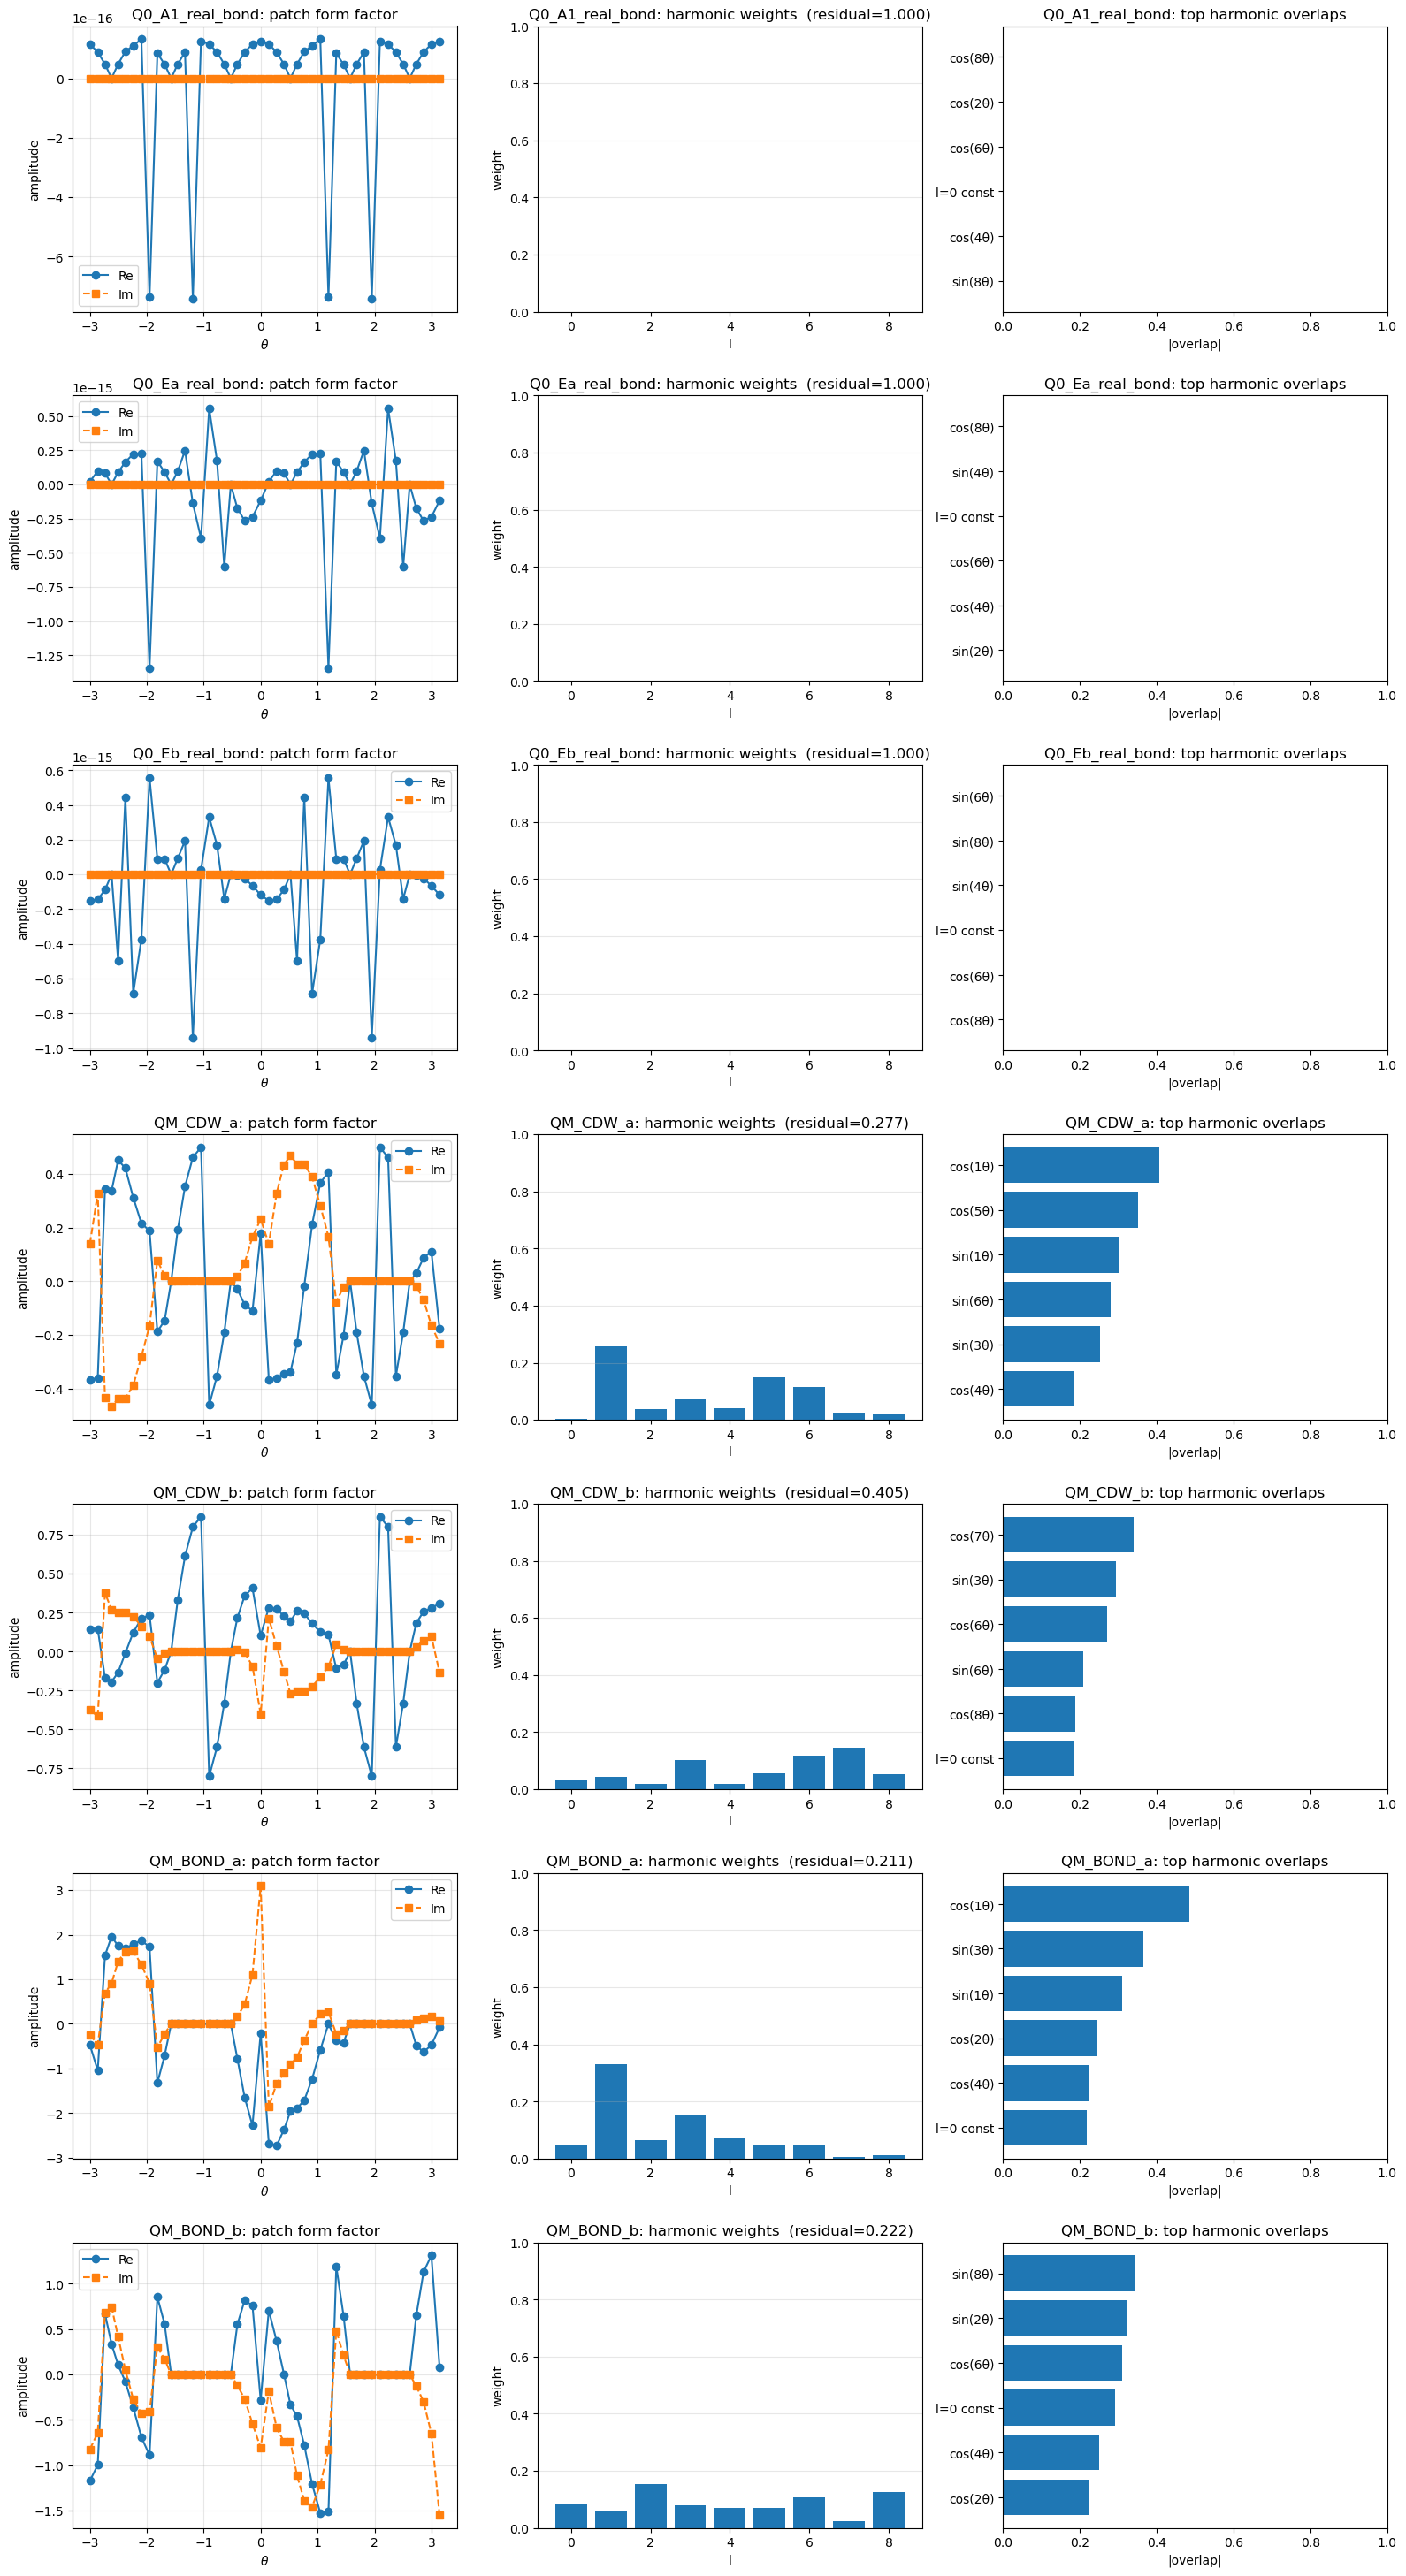


=== Verdict table ===


,test,best_l,best_l_weight,residual,best_raw_template,best_raw_overlap
0,Q0_A1_real_bond,8,4.797338e-31,1.000000,cos(8θ),6.926248e-16
1,Q0_Ea_real_bond,8,7.480975e-31,1.000000,cos(8θ),8.553967e-16
2,Q0_Eb_real_bond,6,4.780913e-31,1.000000,sin(6θ),6.208540e-16
3,QM_CDW_a,1,2.567052e-01,0.277406,cos(1θ),4.063354e-01
4,QM_CDW_b,7,1.470051e-01,0.404801,cos(7θ),3.406944e-01
5,QM_BOND_a,1,3.318940e-01,0.210621,cos(1θ),4.859478e-01
6,QM_BOND_b,2,1.542159e-01,0.221641,sin(8θ),3.456903e-01


In [7]:
# ============================================================
# Test battery for NON-CURRENT form factors on kagome:
#   A) Q=0 real bond nematic / PI-like (E-type)
#   B) Q=M CDW-like sublattice density wave
#   C) Q=M real bond-wave (CBO/SBO-like momentum structure)
#
# Goal:
#   check whether harmonic states can effectively represent these
#   NON-current templates, in contrast to the Nagaosa current test.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# make sure local project folder is importable
sys.path.append(str(Path(".").resolve()))

import noninteracting as nonint
import patching

KagomeNagaosa = nonint.KagomeNagaosa
KagomeKaneMeleSOC = nonint.KagomeKaneMeleSOC
build_exactM_patchset = patching.build_exactM_patchset
hex_bz_vertices = patching.hex_bz_vertices
exact_M6_points_1bz = patching.exact_M6_points_1bz

# ------------------------------------------------------------
# User controls
# ------------------------------------------------------------
MODEL_KIND = "nagaosa"      # "nagaosa" or "kanemele_l1"
TARGET_FILLING = 5.0 / 12.0
BAND_INDEX = 1
POINTS_PER_EDGE = 8
LMAX = 8

# model parameters
T_HOP = 1.0
PHI_EVAL = 0.30
L1_EVAL  = 0.30
L2_EVAL  = 0.00

# patch / geometry
PROJECT_TO_FS_POINTS = True
GAUGE_FIX = True
CLOSE_LOOP_GAUGE = True
GAUGE_ANCHOR = "max_component"
REMOVE_DUPLICATE_M_MODG = False
EF_GRID_N = 140
BZ_GRID_N = 65

# choose which M point for Q=M tests
M_INDEX = 0   # 0..5 among the six geometric M points

# ------------------------------------------------------------
# Model construction
# ------------------------------------------------------------
if MODEL_KIND.lower() == "nagaosa":
    model = KagomeNagaosa({"t": T_HOP, "phi": PHI_EVAL}, spin=False, B=None)
elif MODEL_KIND.lower() == "kanemele_l1":
    model = KagomeKaneMeleSOC({"t": T_HOP, "l1": L1_EVAL, "l2": L2_EVAL}, spin=False, B=None)
else:
    raise ValueError("MODEL_KIND must be 'nagaosa' or 'kanemele_l1'")

mu = model.EF_from_filling(TARGET_FILLING, N=EF_GRID_N)

patchset = build_exactM_patchset(
    model,
    slice(0, 3),
    BAND_INDEX,
    points_per_edge=POINTS_PER_EDGE,
    remove_duplicate_M_modG=REMOVE_DUPLICATE_M_MODG,
    gauge_fix=GAUGE_FIX,
    close_loop_gauge=CLOSE_LOOP_GAUGE,
    gauge_anchor=GAUGE_ANCHOR,
    project_to_fs_points=PROJECT_TO_FS_POINTS,
    mu=mu,
)

M_points = np.asarray(exact_M6_points_1bz(model), dtype=float)
Q_M = np.asarray(M_points[M_INDEX], dtype=float)

print("MODEL_KIND     =", MODEL_KIND)
print("mu             =", mu)
print("Npatch         =", patchset.Npatch)
print("BAND_INDEX     =", BAND_INDEX)
print("Chosen Q_M     =", Q_M)

# ------------------------------------------------------------
# Helpers: patch angles and harmonics
# ------------------------------------------------------------
def normalize(v, tol=1e-14):
    v = np.asarray(v, dtype=complex).reshape(-1)
    n = np.linalg.norm(v)
    if n < tol:
        return v.copy()
    return v / n

def orthonormalize_templates(vecs, tol=1e-12):
    out = []
    for v in vecs:
        w = np.asarray(v, dtype=complex).copy()
        for b in out:
            w = w - np.vdot(b, w) * b
        nrm = np.linalg.norm(w)
        if nrm > tol:
            out.append(w / nrm)
    return out

def patch_angles_from_patchset(ps):
    ks = np.asarray(ps.patch_k, dtype=float)
    theta = np.arctan2(ks[:, 1], ks[:, 0])
    return ks, theta

def build_harmonic_subspaces(theta, lmax):
    theta = np.asarray(theta, dtype=float)
    N = len(theta)

    subspaces = {}
    raw_templates = []

    L0 = np.ones(N, dtype=float)
    B0 = orthonormalize_templates([L0])
    subspaces[0] = B0
    raw_templates.append(("l=0 const", normalize(L0)))

    for l in range(1, lmax + 1):
        c = np.cos(l * theta)
        s = np.sin(l * theta)
        B = orthonormalize_templates([c, s])
        subspaces[l] = B
        raw_templates.append((f"cos({l}θ)", normalize(c)))
        raw_templates.append((f"sin({l}θ)", normalize(s)))

    return subspaces, raw_templates

def subspace_weight(vec, basis):
    v = normalize(vec)
    if len(basis) == 0:
        return 0.0
    B = np.column_stack([normalize(b) for b in basis])
    coeff = B.conjugate().T @ v
    return float(np.real(np.vdot(coeff, coeff)))

def raw_overlap_abs(vec, template):
    return float(np.abs(np.vdot(normalize(vec), normalize(template))))

# ------------------------------------------------------------
# Basic kagome orbital operators
# ------------------------------------------------------------
# orbital indices: A=0, B=1, C=2
A, B, C = 0, 1, 2

def bond_matrix_ab():
    M = np.zeros((3, 3), dtype=complex)
    M[A, B] = 1.0
    M[B, A] = 1.0
    return M

def bond_matrix_ac():
    M = np.zeros((3, 3), dtype=complex)
    M[A, C] = 1.0
    M[C, A] = 1.0
    return M

def bond_matrix_bc():
    M = np.zeros((3, 3), dtype=complex)
    M[B, C] = 1.0
    M[C, B] = 1.0
    return M

def density_diag(vec):
    return np.diag(np.asarray(vec, dtype=float))

M_AB = bond_matrix_ab()
M_AC = bond_matrix_ac()
M_BC = bond_matrix_bc()

# ------------------------------------------------------------
# Real-bond operators at Q=0
#   These are the real counterparts of anisotropic bond order,
#   not current operators.
# ------------------------------------------------------------
def real_bond_ops_Q0(model, kx, ky):
    k = np.array([kx, ky], dtype=float)
    c1 = np.cos(np.dot(model.delta1, k))
    c2 = np.cos(np.dot(model.delta2, k))
    c3 = np.cos(np.dot(model.delta3, k))

    B1 = (-2.0 * c1) * M_AB
    B2 = (-2.0 * c2) * M_AC
    B3 = (-2.0 * c3) * M_BC
    return B1, B2, B3

def operator_A1_bond(model, kx, ky):
    B1, B2, B3 = real_bond_ops_Q0(model, kx, ky)
    O = B1 + B2 + B3
    return 0.5 * (O + O.conjugate().T)

def operator_Ea_bond(model, kx, ky):
    # one E-type partner: 2B1 - B2 - B3
    B1, B2, B3 = real_bond_ops_Q0(model, kx, ky)
    O = 2.0 * B1 - B2 - B3
    return 0.5 * (O + O.conjugate().T)

def operator_Eb_bond(model, kx, ky):
    # the other E-type partner: B2 - B3
    B1, B2, B3 = real_bond_ops_Q0(model, kx, ky)
    O = B2 - B3
    return 0.5 * (O + O.conjugate().T)

# ------------------------------------------------------------
# Finite-Q site-density templates (CDW / SDW momentum structure)
#   Spin structure is NOT included here.
#   For spinless noninteracting test, charge vs spin share the same
#   k-space form factor. Only the orbital / momentum structure matters.
# ------------------------------------------------------------
D_M_a = density_diag([1.0, -1.0, 0.0])
D_M_b = density_diag([1.0, 1.0, -2.0]) / np.sqrt(3.0)

# ------------------------------------------------------------
# Finite-Q real bond-wave templates
#   Heuristic real bond operator connecting k -> k+Q.
#   This captures the momentum structure of a real bond modulation.
# ------------------------------------------------------------
def bond_wave_ops_Q(model, kx, ky, Q):
    k = np.array([kx, ky], dtype=float)
    q = np.array(Q, dtype=float)

    # natural real bond wave factor: cos((k + Q/2) · delta_i)
    x1 = np.cos(np.dot(model.delta1, k + 0.5 * q))
    x2 = np.cos(np.dot(model.delta2, k + 0.5 * q))
    x3 = np.cos(np.dot(model.delta3, k + 0.5 * q))

    B1 = (2.0 * x1) * M_AB
    B2 = (2.0 * x2) * M_AC
    B3 = (2.0 * x3) * M_BC
    return B1, B2, B3

def operator_M_bond_a(model, kx, ky, Q):
    B1, B2, B3 = bond_wave_ops_Q(model, kx, ky, Q)
    O = 2.0 * B1 - B2 - B3
    return 0.5 * (O + O.conjugate().T)

def operator_M_bond_b(model, kx, ky, Q):
    B1, B2, B3 = bond_wave_ops_Q(model, kx, ky, Q)
    O = B2 - B3
    return 0.5 * (O + O.conjugate().T)

# ------------------------------------------------------------
# Band-projected form factors
# ------------------------------------------------------------
def ff_Q0(model, kx, ky, band_index, operator_fn):
    evals, evecs = model.eigenstate(kx, ky)
    u = np.asarray(evecs[:, band_index], dtype=complex)
    O = operator_fn(model, kx, ky)
    val = np.vdot(u, O @ u)
    val = np.real_if_close(val, tol=1000)
    return complex(val)

def ff_QM(model, kx, ky, band_index, Q, operator_matrix):
    evals_k, evecs_k = model.eigenstate(kx, ky)
    evals_q, evecs_q = model.eigenstate(kx + Q[0], ky + Q[1])

    uk = np.asarray(evecs_k[:, band_index], dtype=complex)
    uq = np.asarray(evecs_q[:, band_index], dtype=complex)

    val = np.vdot(uq, operator_matrix @ uk)
    return complex(val)

def ff_QM_operator_fn(model, kx, ky, band_index, Q, operator_fn):
    evals_k, evecs_k = model.eigenstate(kx, ky)
    evals_q, evecs_q = model.eigenstate(kx + Q[0], ky + Q[1])

    uk = np.asarray(evecs_k[:, band_index], dtype=complex)
    uq = np.asarray(evecs_q[:, band_index], dtype=complex)

    O = operator_fn(model, kx, ky, Q)
    val = np.vdot(uq, O @ uk)
    return complex(val)

# ------------------------------------------------------------
# Build patch-space form factors
# ------------------------------------------------------------
patch_k, theta_patch = patch_angles_from_patchset(patchset)

tests = {}

# A) Q=0 real bond nematic / PI-like
tests["Q0_A1_real_bond"] = np.array(
    [ff_Q0(model, kx, ky, BAND_INDEX, operator_A1_bond) for kx, ky in patch_k],
    dtype=complex
)
tests["Q0_Ea_real_bond"] = np.array(
    [ff_Q0(model, kx, ky, BAND_INDEX, operator_Ea_bond) for kx, ky in patch_k],
    dtype=complex
)
tests["Q0_Eb_real_bond"] = np.array(
    [ff_Q0(model, kx, ky, BAND_INDEX, operator_Eb_bond) for kx, ky in patch_k],
    dtype=complex
)

# B) Q=M CDW-like
tests["QM_CDW_a"] = np.array(
    [ff_QM(model, kx, ky, BAND_INDEX, Q_M, D_M_a) for kx, ky in patch_k],
    dtype=complex
)
tests["QM_CDW_b"] = np.array(
    [ff_QM(model, kx, ky, BAND_INDEX, Q_M, D_M_b) for kx, ky in patch_k],
    dtype=complex
)

# C) Q=M real bond-wave
tests["QM_BOND_a"] = np.array(
    [ff_QM_operator_fn(model, kx, ky, BAND_INDEX, Q_M, operator_M_bond_a) for kx, ky in patch_k],
    dtype=complex
)
tests["QM_BOND_b"] = np.array(
    [ff_QM_operator_fn(model, kx, ky, BAND_INDEX, Q_M, operator_M_bond_b) for kx, ky in patch_k],
    dtype=complex
)

# ------------------------------------------------------------
# Harmonic analysis
# ------------------------------------------------------------
harmonic_subspaces, raw_harmonics = build_harmonic_subspaces(theta_patch, LMAX)

summary_rows = []
raw_rows = []

for name, vec in tests.items():
    v = normalize(vec)

    sumw = 0.0
    weights = []
    for l in range(0, LMAX + 1):
        w = subspace_weight(v, harmonic_subspaces[l])
        sumw += w
        weights.append(w)
        summary_rows.append({
            "test": name,
            "l": l,
            "subspace_weight": w,
        })
    summary_rows.append({
        "test": name,
        "l": "residual",
        "subspace_weight": max(0.0, 1.0 - sumw),
    })

    for label, templ in raw_harmonics:
        raw_rows.append({
            "test": name,
            "template": label,
            "abs_overlap": raw_overlap_abs(v, templ),
        })

df_summary = pd.DataFrame(summary_rows)
df_raw = pd.DataFrame(raw_rows)

print("\n=== Harmonic subspace summary ===")
display(df_summary)

print("\n=== Top raw overlaps for each test ===")
for name in tests.keys():
    print(f"\n--- {name} ---")
    display(
        df_raw[df_raw["test"] == name]
        .sort_values("abs_overlap", ascending=False)
        .head(8)
        .reset_index(drop=True)
    )

# ------------------------------------------------------------
# Plot all tests
# ------------------------------------------------------------
n_tests = len(tests)
fig, axes = plt.subplots(n_tests, 3, figsize=(16, 4.2 * n_tests))
if n_tests == 1:
    axes = np.array([axes])

for row_idx, (name, vec) in enumerate(tests.items()):
    v = np.asarray(vec, dtype=complex)
    vn = normalize(v)

    order = np.argsort(theta_patch)
    th = theta_patch[order]

    # panel 1: Re/Im on patch ring
    ax = axes[row_idx, 0]
    ax.plot(th, np.real(v[order]), "o-", label="Re")
    ax.plot(th, np.imag(v[order]), "s--", label="Im")
    ax.set_title(f"{name}: patch form factor")
    ax.set_xlabel(r"$\theta$")
    ax.set_ylabel("amplitude")
    ax.grid(alpha=0.3)
    ax.legend()

    # panel 2: harmonic weights
    ax = axes[row_idx, 1]
    sub = df_summary[(df_summary["test"] == name) & (df_summary["l"] != "residual")].copy()
    ax.bar(sub["l"].astype(int), sub["subspace_weight"].astype(float))
    residual = df_summary[(df_summary["test"] == name) & (df_summary["l"] == "residual")]["subspace_weight"].iloc[0]
    ax.set_ylim(0, 1.0)
    ax.set_title(f"{name}: harmonic weights  (residual={residual:.3f})")
    ax.set_xlabel("l")
    ax.set_ylabel("weight")
    ax.grid(alpha=0.3, axis="y")

    # panel 3: top 6 raw overlaps
    ax = axes[row_idx, 2]
    raw_top = (
        df_raw[df_raw["test"] == name]
        .sort_values("abs_overlap", ascending=False)
        .head(6)
        .iloc[::-1]
    )
    ax.barh(raw_top["template"], raw_top["abs_overlap"])
    ax.set_xlim(0, 1.0)
    ax.set_title(f"{name}: top harmonic overlaps")
    ax.set_xlabel("|overlap|")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Compact verdict table
# ------------------------------------------------------------
verdict_rows = []
for name in tests.keys():
    sub = df_summary[(df_summary["test"] == name) & (df_summary["l"] != "residual")]
    residual = df_summary[(df_summary["test"] == name) & (df_summary["l"] == "residual")]["subspace_weight"].iloc[0]
    best_l = int(sub.sort_values("subspace_weight", ascending=False).iloc[0]["l"])
    best_l_weight = float(sub.sort_values("subspace_weight", ascending=False).iloc[0]["subspace_weight"])
    best_raw = (
        df_raw[df_raw["test"] == name]
        .sort_values("abs_overlap", ascending=False)
        .iloc[0]
    )
    verdict_rows.append({
        "test": name,
        "best_l": best_l,
        "best_l_weight": best_l_weight,
        "residual": float(residual),
        "best_raw_template": best_raw["template"],
        "best_raw_overlap": float(best_raw["abs_overlap"]),
    })

df_verdict = pd.DataFrame(verdict_rows)
print("\n=== Verdict table ===")
display(df_verdict)